In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

# Load the dataset
df = pd.read_csv('data/clean-dataset.csv')

# Generate the profiling report
profile = ProfileReport(df, title="PPG Dataset Profiling Report", explorative=True)

# Save the report as an HTML file
profile.to_file("ppg_profiling_report.html")

print("Profiling report saved to ppg_profiling_report.html")
print(f"\nDataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Exploratory Data Analysis - PPG Dataset

This notebook performs comprehensive EDA on the clean PPG dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('data/clean-dataset.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head(10)

Dataset Shape: 844,946 rows × 13 columns

First few rows:


,PPG_Signal,Patient_Id,Heart_Rate,Systolic_Peak,Diastolic_Peak,Pulse_Area,index,Gender,Age,Glucose_level,Height,Weight,pl
0,511,1,77.0,522.0,505.0,393.0,0,1,38,99,180,53,1
1,511,1,77.0,522.0,505.0,393.0,1,1,38,102,180,53,2
2,511,1,77.0,522.0,505.0,393.0,2,1,38,103,180,53,3
3,511,1,77.0,522.0,505.0,393.0,3,1,38,128,180,53,4
4,511,1,77.0,522.0,505.0,393.0,4,1,38,130,180,53,5
5,511,1,77.0,522.0,505.0,393.0,5,1,38,134,180,53,6
6,511,1,77.0,522.0,505.0,393.0,6,1,38,136,180,53,7
7,511,1,77.0,522.0,505.0,393.0,0,1,38,99,180,53,8
8,511,1,77.0,522.0,505.0,393.0,1,1,38,102,180,53,9
9,511,1,77.0,522.0,505.0,393.0,2,1,38,103,180,53,10


In [3]:
# Dataset info
print("Column Data Types and Non-Null Counts:")
df.info()

Column Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844946 entries, 0 to 844945
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PPG_Signal      844946 non-null  int64  
 1   Patient_Id      844946 non-null  int64  
 2   Heart_Rate      844946 non-null  float64
 3   Systolic_Peak   844946 non-null  float64
 4   Diastolic_Peak  844946 non-null  float64
 5   Pulse_Area      844946 non-null  float64
 6   index           844946 non-null  int64  
 7   Gender          844946 non-null  int64  
 8   Age             844946 non-null  int64  
 9   Glucose_level   844946 non-null  int64  
 10  Height          844946 non-null  int64  
 11  Weight          844946 non-null  int64  
 12  pl              844946 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 83.8 MB


## 2. Data Quality Check

In [4]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates:,}")

Missing Values:
PPG_Signal        0
Patient_Id        0
Heart_Rate        0
Systolic_Peak     0
Diastolic_Peak    0
Pulse_Area        0
index             0
Gender            0
Age               0
Glucose_level     0
Height            0
Weight            0
pl                0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


## 3. Statistical Summary

In [5]:
# Statistical summary of numerical features
df.describe()

,PPG_Signal,Patient_Id,Heart_Rate,Systolic_Peak,Diastolic_Peak,Pulse_Area,index,Gender,Age,Glucose_level,Height,Weight,pl
count,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,844946.000000,8.449460e+05
mean,511.220492,10.176868,77.351428,520.695705,507.621016,396.777973,31.672260,0.762582,32.117474,115.405805,175.802004,67.331677,7.098505e+05
std,2.043421,7.291117,8.394428,3.213949,1.832483,43.691605,20.459795,0.425500,9.838952,19.077954,7.533466,17.197792,4.467891e+05
min,506.000000,1.000000,61.000000,514.000000,504.000000,309.500000,0.000000,0.000000,22.000000,88.000000,154.000000,42.000000,1.000000e+00
25%,510.000000,5.000000,73.000000,519.000000,507.000000,374.000000,13.000000,1.000000,24.000000,102.000000,170.000000,53.000000,3.841152e+05
50%,511.000000,9.000000,78.000000,521.000000,508.000000,390.000000,32.000000,1.000000,27.000000,110.000000,178.000000,60.000000,6.935505e+05
75%,512.000000,17.000000,81.000000,523.000000,509.000000,417.000000,52.000000,1.000000,38.000000,128.000000,180.000000,88.000000,1.117459e+06
max,517.000000,23.000000,93.000000,529.000000,512.000000,481.500000,66.000000,1.000000,61.000000,183.000000,187.000000,103.000000,1.463372e+06


In [6]:
# Unique value counts for each column
print("Unique Values per Column:")
for col in df.columns:
    print(f"{col:20}: {df[col].nunique():>10,} unique values")

Unique Values per Column:
PPG_Signal          :         12 unique values
Patient_Id          :         22 unique values
Heart_Rate          :         32 unique values
Systolic_Peak       :         16 unique values
Diastolic_Peak      :          9 unique values
Pulse_Area          :         92 unique values
index               :         62 unique values
Gender              :          2 unique values
Age                 :         16 unique values
Glucose_level       :         28 unique values
Height              :         14 unique values
Weight              :         18 unique values
pl                  :    844,946 unique values


## 4. Patient Demographics Analysis

In [7]:
# Patient demographics
print(f"Total Unique Patients: {df['Patient_Id'].nunique()}")
print(f"\nGender Distribution:")
print(df['Gender'].value_counts())
print(f"\nAge Statistics:")
print(f"  Min Age: {df['Age'].min()}")
print(f"  Max Age: {df['Age'].max()}")
print(f"  Mean Age: {df['Age'].mean():.1f}")
print(f"  Median Age: {df['Age'].median():.1f}")

Total Unique Patients: 22

Gender Distribution:
Gender
1    644341
0    200605
Name: count, dtype: int64

Age Statistics:
  Min Age: 22
  Max Age: 61
  Mean Age: 32.1
  Median Age: 27.0


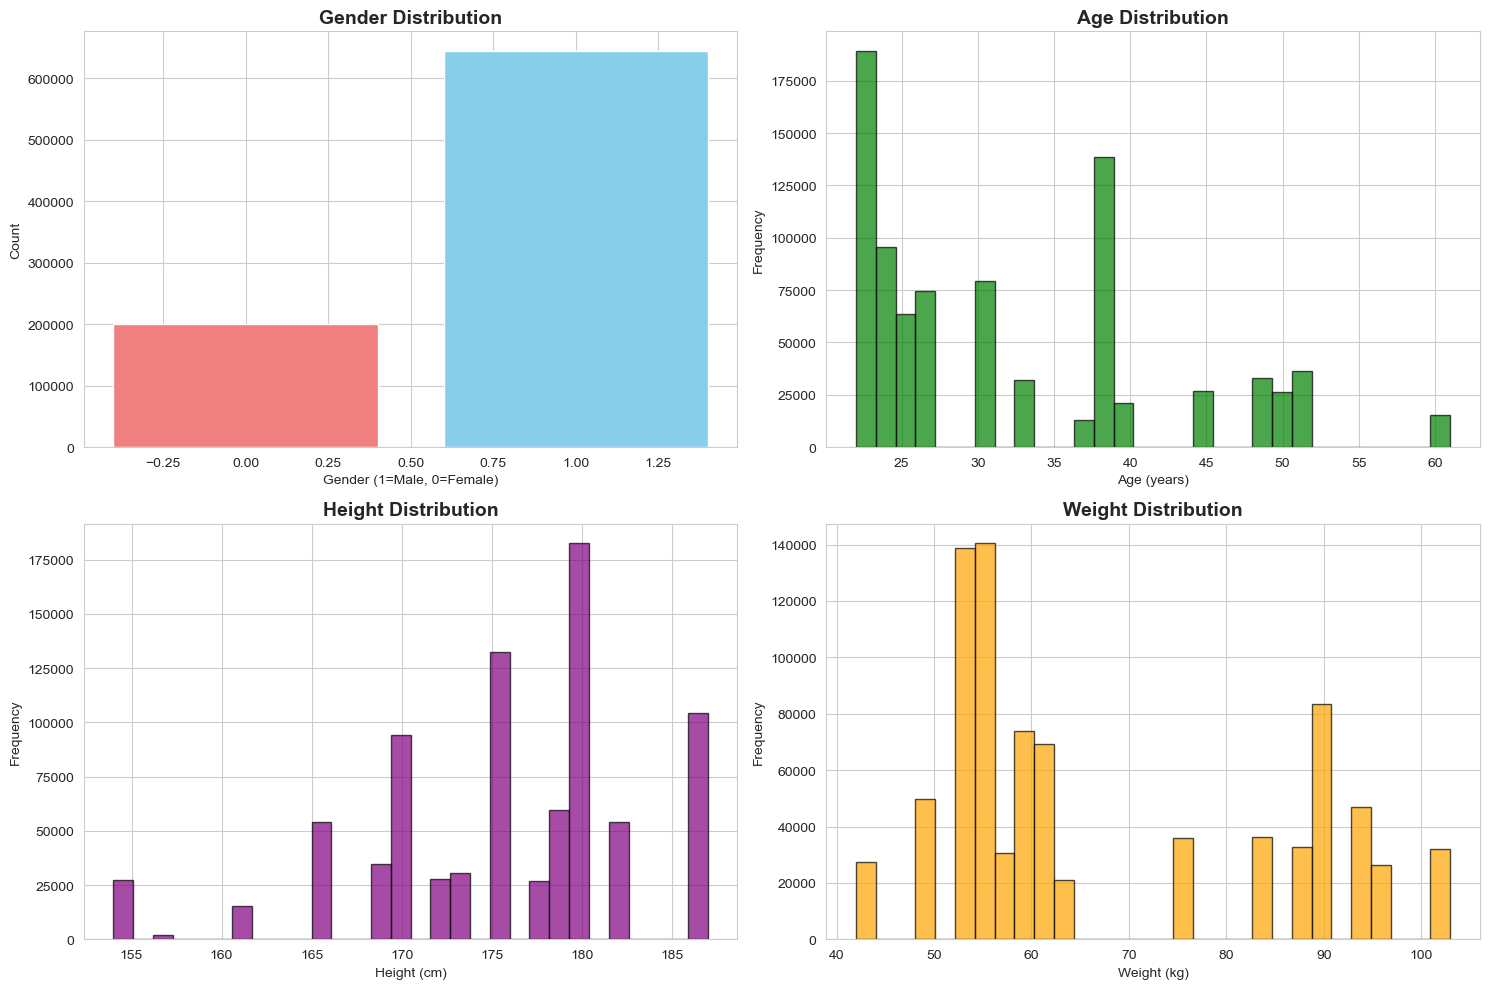

In [8]:
# Visualize demographics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'])
axes[0, 0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Gender (1=Male, 0=Female)')
axes[0, 0].set_ylabel('Count')

# Age distribution
axes[0, 1].hist(df['Age'].dropna(), bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Frequency')

# Height distribution
axes[1, 0].hist(df['Height'].dropna(), bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Height Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Height (cm)')
axes[1, 0].set_ylabel('Frequency')

# Weight distribution
axes[1, 1].hist(df['Weight'].dropna(), bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Weight Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Weight (kg)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. PPG Signal Analysis

In [9]:
# PPG signal features
ppg_features = ['PPG_Signal', 'Heart_Rate', 'Systolic_Peak', 'Diastolic_Peak', 'Pulse_Area']

print("PPG Signal Features Summary:")
print(df[ppg_features].describe())

PPG Signal Features Summary:
          PPG_Signal     Heart_Rate  Systolic_Peak  Diastolic_Peak  \
count  844946.000000  844946.000000  844946.000000   844946.000000   
mean      511.220492      77.351428     520.695705      507.621016   
std         2.043421       8.394428       3.213949        1.832483   
min       506.000000      61.000000     514.000000      504.000000   
25%       510.000000      73.000000     519.000000      507.000000   
50%       511.000000      78.000000     521.000000      508.000000   
75%       512.000000      81.000000     523.000000      509.000000   
max       517.000000      93.000000     529.000000      512.000000   

          Pulse_Area  
count  844946.000000  
mean      396.777973  
std        43.691605  
min       309.500000  
25%       374.000000  
50%       390.000000  
75%       417.000000  
max       481.500000  


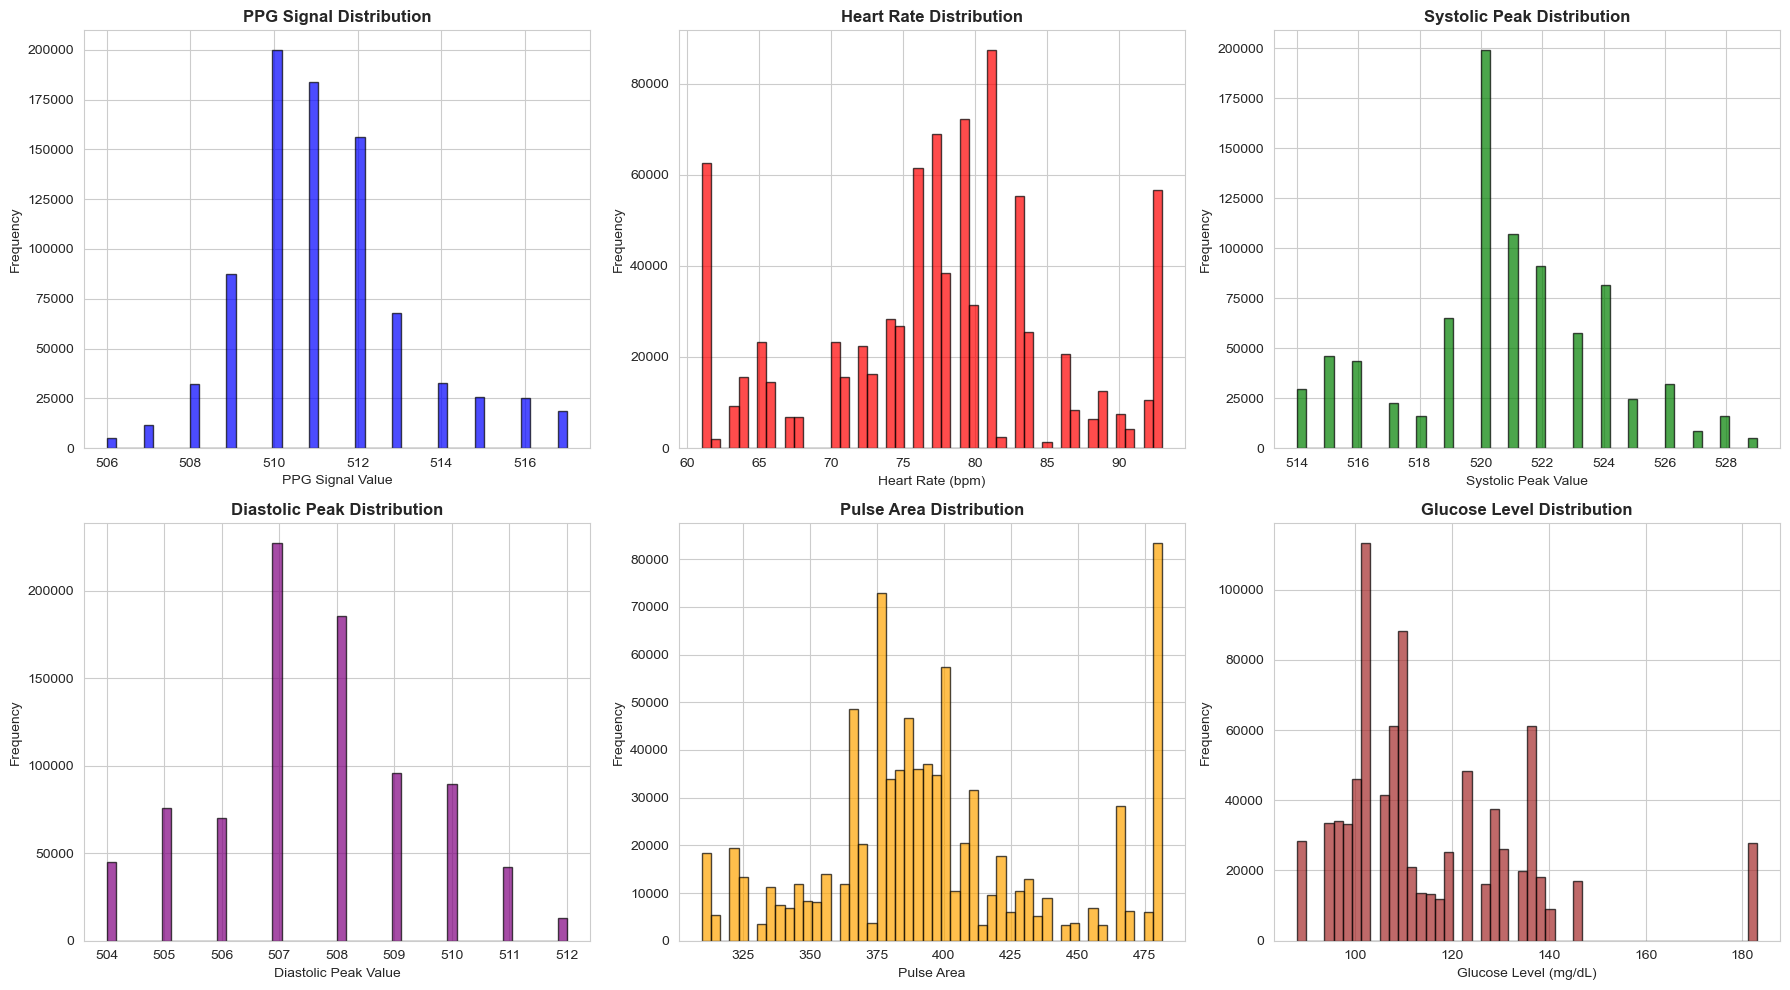

In [10]:
# Visualize PPG signal features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# PPG Signal
axes[0, 0].hist(df['PPG_Signal'].dropna(), bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('PPG Signal Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('PPG Signal Value')
axes[0, 0].set_ylabel('Frequency')

# Heart Rate
axes[0, 1].hist(df['Heart_Rate'].dropna(), bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Heart Rate Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Heart Rate (bpm)')
axes[0, 1].set_ylabel('Frequency')

# Systolic Peak
axes[0, 2].hist(df['Systolic_Peak'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Systolic Peak Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Systolic Peak Value')
axes[0, 2].set_ylabel('Frequency')

# Diastolic Peak
axes[1, 0].hist(df['Diastolic_Peak'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Diastolic Peak Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Diastolic Peak Value')
axes[1, 0].set_ylabel('Frequency')

# Pulse Area
axes[1, 1].hist(df['Pulse_Area'].dropna(), bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Pulse Area Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Pulse Area')
axes[1, 1].set_ylabel('Frequency')

# Glucose Level
axes[1, 2].hist(df['Glucose_level'].dropna(), bins=50, color='brown', alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Glucose Level Distribution', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Glucose Level (mg/dL)')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

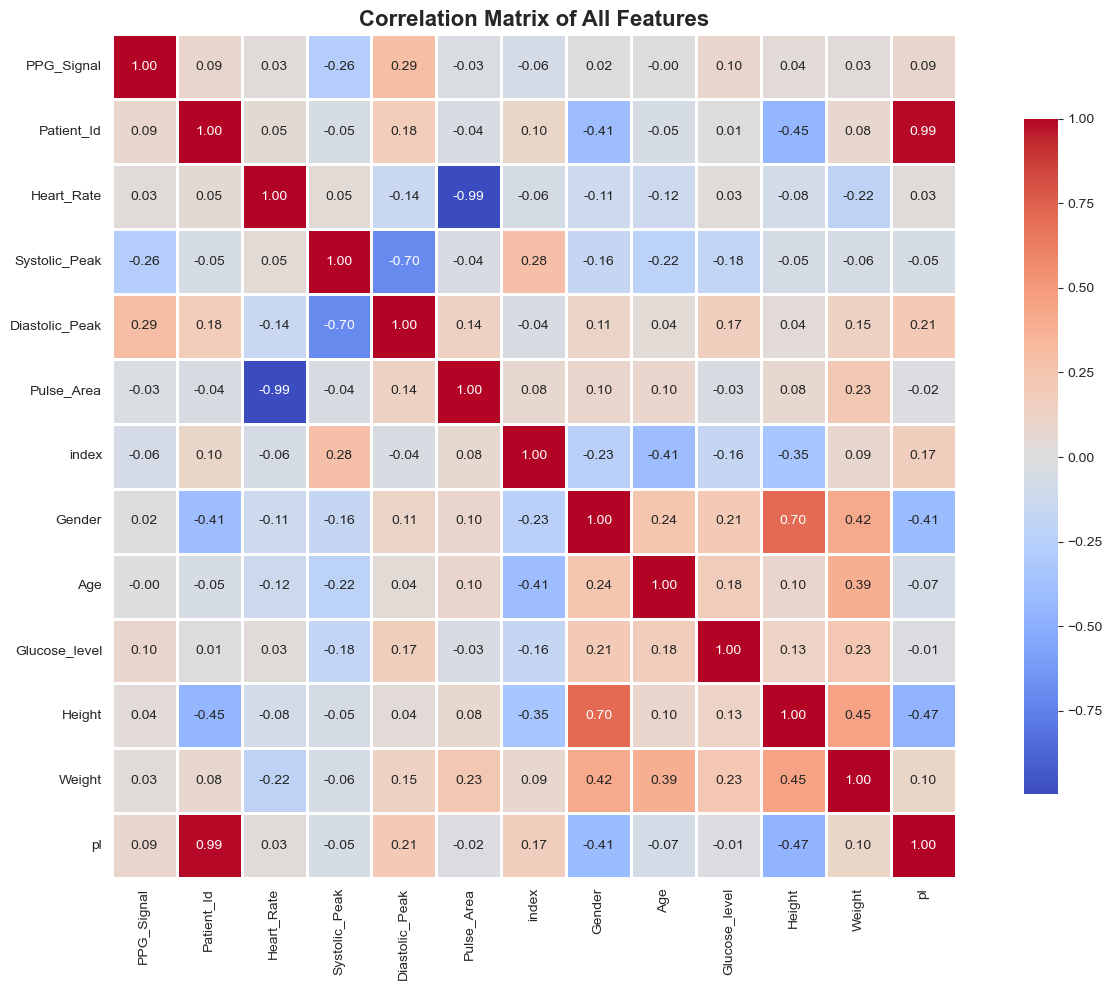

In [11]:
# Correlation matrix
correlation_matrix = df.corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Find highly correlated features
threshold = 0.7
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print("Highly Correlated Feature Pairs (|correlation| > 0.7):")
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated feature pairs found (threshold = 0.7)")

Highly Correlated Feature Pairs (|correlation| > 0.7):
 Feature 1  Feature 2  Correlation
Patient_Id         pl     0.991944
    Gender     Height     0.704426
Heart_Rate Pulse_Area    -0.994983


## 7. Glucose Level Analysis

In [13]:
# Glucose level statistics
print("Glucose Level Statistics:")
print(f"  Min: {df['Glucose_level'].min():.1f} mg/dL")
print(f"  Max: {df['Glucose_level'].max():.1f} mg/dL")
print(f"  Mean: {df['Glucose_level'].mean():.1f} mg/dL")
print(f"  Median: {df['Glucose_level'].median():.1f} mg/dL")
print(f"  Std Dev: {df['Glucose_level'].std():.1f} mg/dL")

# Categorize glucose levels (simplified classification)
# Normal: < 100, Prediabetes: 100-125, Diabetes: >= 126
df['Glucose_Category'] = pd.cut(df['Glucose_level'], 
                                  bins=[0, 100, 126, float('inf')],
                                  labels=['Normal', 'Prediabetes', 'Diabetes'])

print(f"\nGlucose Level Categories:")
print(df['Glucose_Category'].value_counts())

Glucose Level Statistics:
  Min: 88.0 mg/dL
  Max: 183.0 mg/dL
  Mean: 115.4 mg/dL
  Median: 110.0 mg/dL
  Std Dev: 19.1 mg/dL

Glucose Level Categories:
Glucose_Category
Prediabetes    437030
Diabetes       232789
Normal         175127
Name: count, dtype: int64


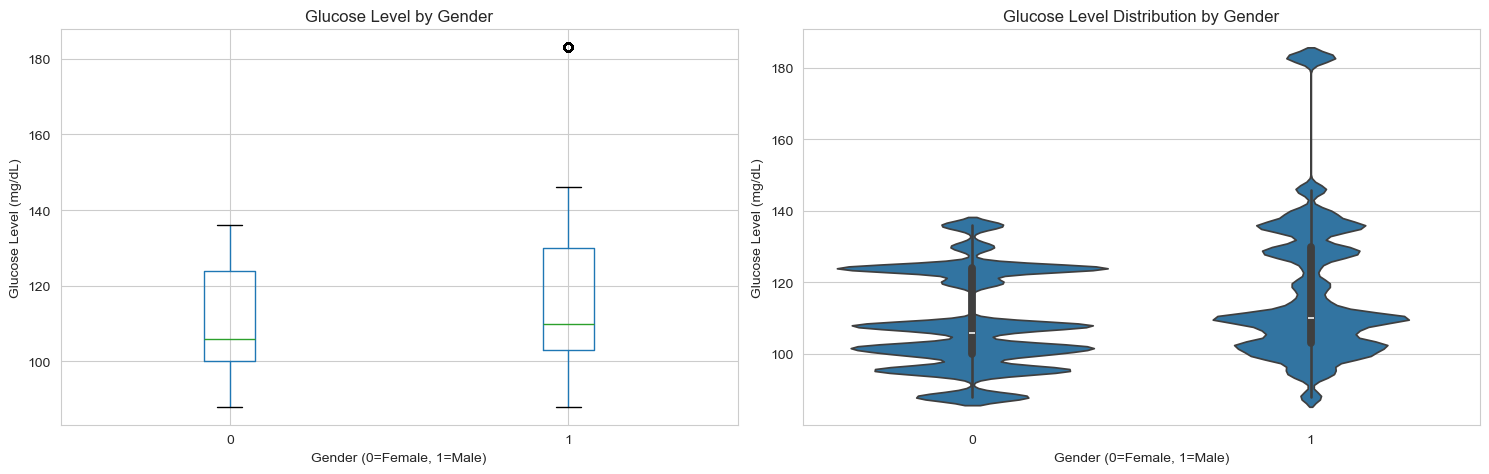

In [14]:
# Glucose level by gender
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
df.boxplot(column='Glucose_level', by='Gender', ax=axes[0])
axes[0].set_title('Glucose Level by Gender')
axes[0].set_xlabel('Gender (0=Female, 1=Male)')
axes[0].set_ylabel('Glucose Level (mg/dL)')
plt.suptitle('')

# Violin plot
sns.violinplot(data=df, x='Gender', y='Glucose_level', ax=axes[1])
axes[1].set_title('Glucose Level Distribution by Gender')
axes[1].set_xlabel('Gender (0=Female, 1=Male)')
axes[1].set_ylabel('Glucose Level (mg/dL)')

plt.tight_layout()
plt.show()

## 8. Relationships Between Features

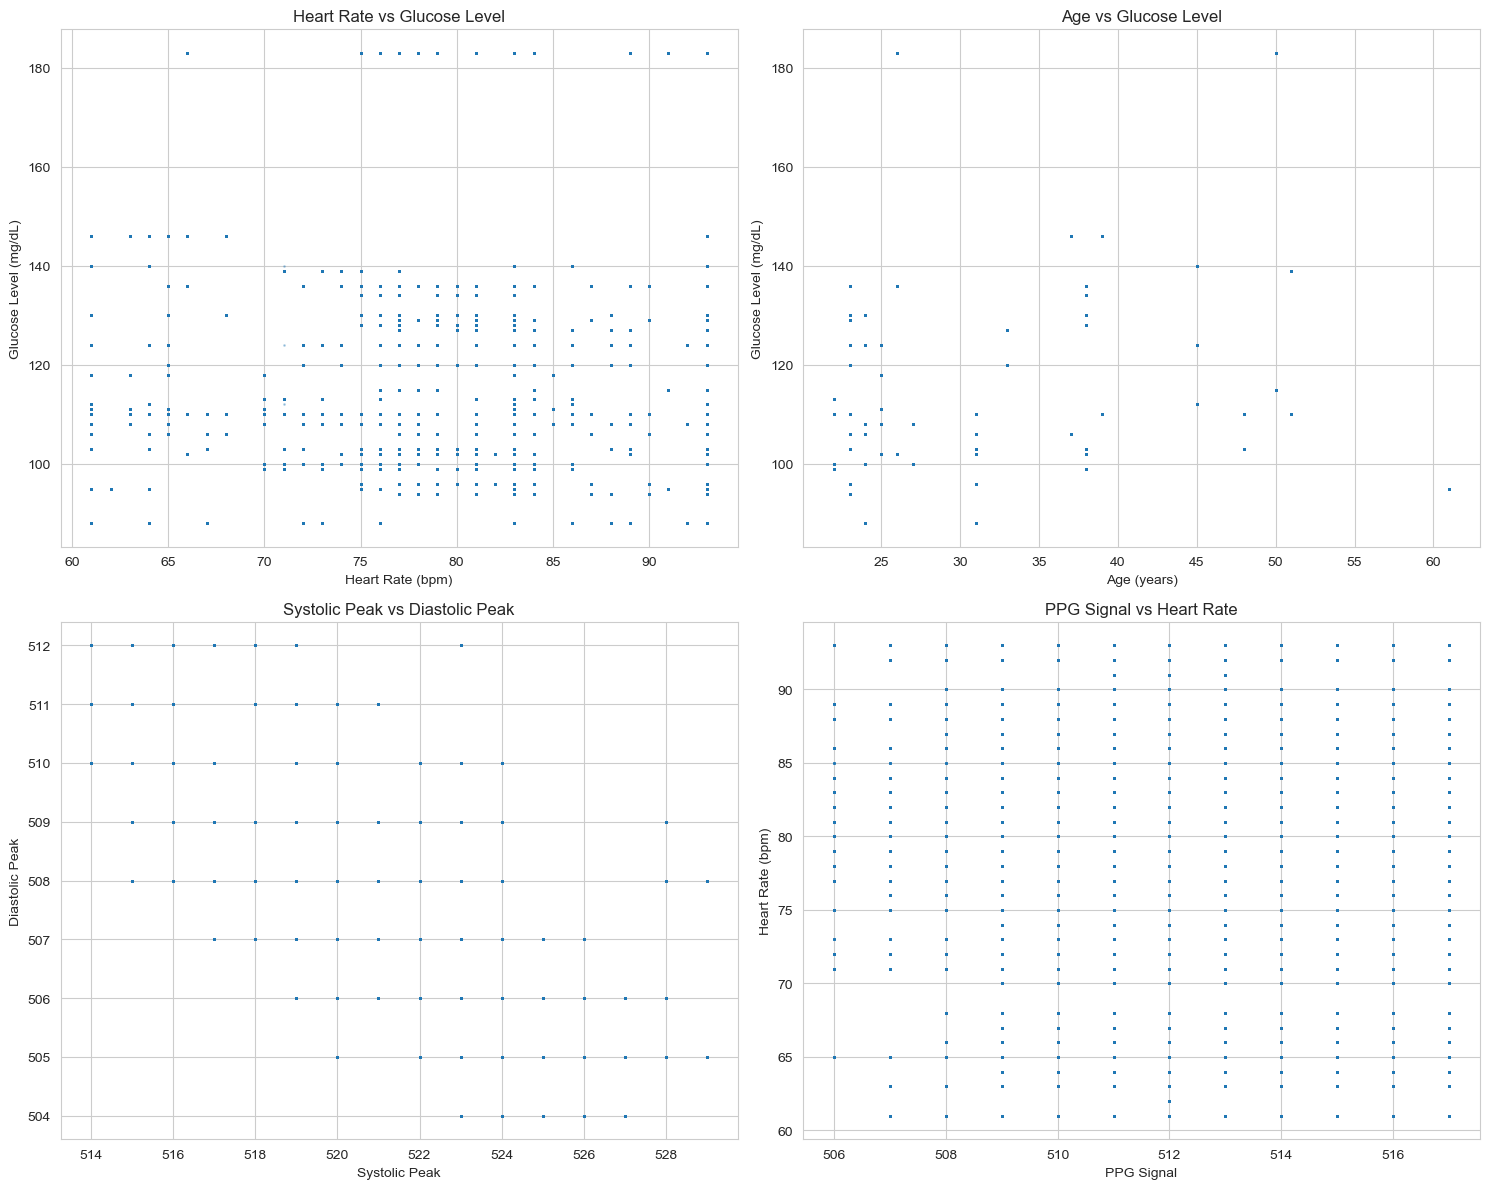

In [15]:
# Scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Heart Rate vs Glucose Level
axes[0, 0].scatter(df['Heart_Rate'], df['Glucose_level'], alpha=0.3, s=1)
axes[0, 0].set_xlabel('Heart Rate (bpm)')
axes[0, 0].set_ylabel('Glucose Level (mg/dL)')
axes[0, 0].set_title('Heart Rate vs Glucose Level')

# Age vs Glucose Level
axes[0, 1].scatter(df['Age'], df['Glucose_level'], alpha=0.3, s=1)
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Glucose Level (mg/dL)')
axes[0, 1].set_title('Age vs Glucose Level')

# Systolic Peak vs Diastolic Peak
axes[1, 0].scatter(df['Systolic_Peak'], df['Diastolic_Peak'], alpha=0.3, s=1)
axes[1, 0].set_xlabel('Systolic Peak')
axes[1, 0].set_ylabel('Diastolic Peak')
axes[1, 0].set_title('Systolic Peak vs Diastolic Peak')

# PPG Signal vs Heart Rate
axes[1, 1].scatter(df['PPG_Signal'], df['Heart_Rate'], alpha=0.3, s=1)
axes[1, 1].set_xlabel('PPG Signal')
axes[1, 1].set_ylabel('Heart Rate (bpm)')
axes[1, 1].set_title('PPG Signal vs Heart Rate')

plt.tight_layout()
plt.show()

## 9. Patient-Level Analysis

Samples per Patient Statistics:
  Min: 2,170
  Max: 138,763
  Mean: 38,406.6
  Median: 32,417.0


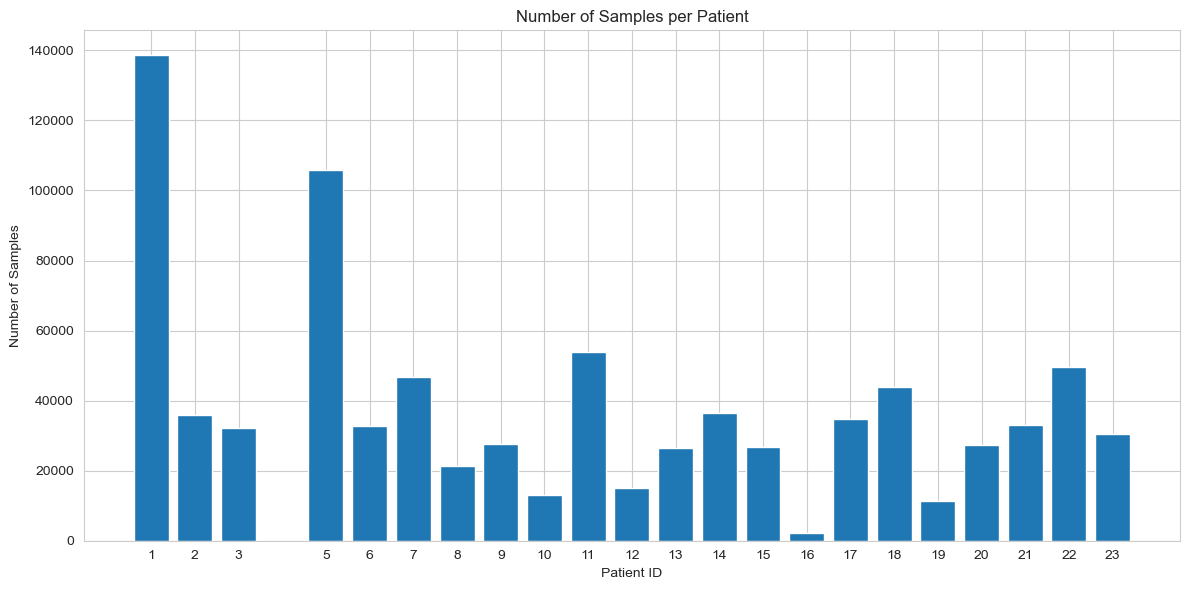

In [16]:
# Samples per patient
samples_per_patient = df.groupby('Patient_Id').size().reset_index(name='Sample_Count')

print(f"Samples per Patient Statistics:")
print(f"  Min: {samples_per_patient['Sample_Count'].min():,}")
print(f"  Max: {samples_per_patient['Sample_Count'].max():,}")
print(f"  Mean: {samples_per_patient['Sample_Count'].mean():,.1f}")
print(f"  Median: {samples_per_patient['Sample_Count'].median():,.1f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(samples_per_patient['Patient_Id'], samples_per_patient['Sample_Count'])
plt.xlabel('Patient ID')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Patient')
plt.xticks(samples_per_patient['Patient_Id'])
plt.tight_layout()
plt.show()

## 10. Outlier Detection

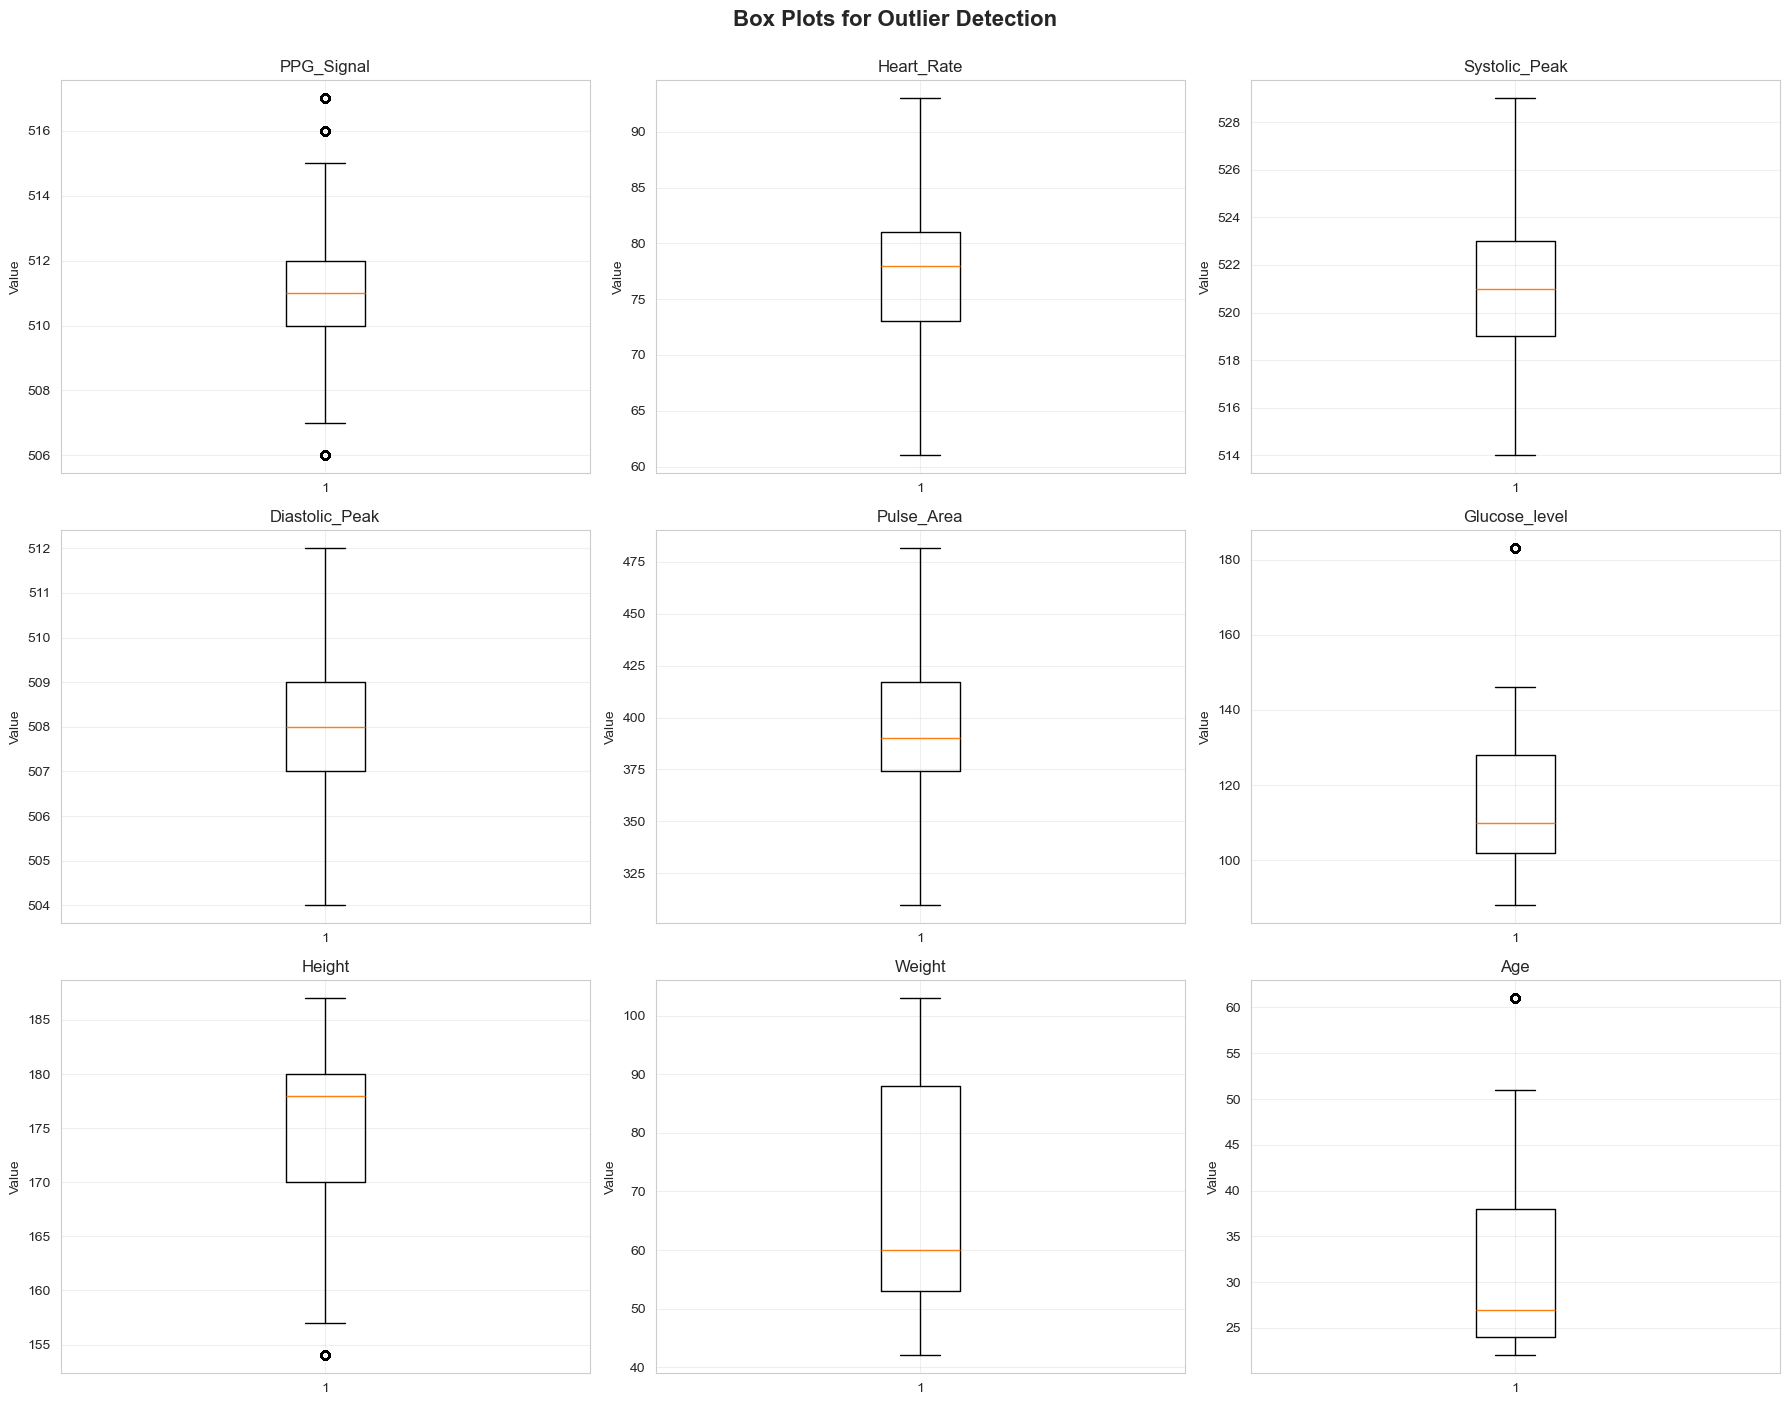

In [17]:
# Box plots to identify outliers
numeric_features = ['PPG_Signal', 'Heart_Rate', 'Systolic_Peak', 'Diastolic_Peak', 
                    'Pulse_Area', 'Glucose_level', 'Height', 'Weight', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for idx, feature in enumerate(numeric_features):
    axes[idx].boxplot(df[feature].dropna())
    axes[idx].set_title(f'{feature}')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()